# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Adrián Cardona Young

**ID**: alc354

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\adric\OneDrive - Cornell University\Documents\3. Env Sys Analysis\bee4750-hw1-alc354`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [4]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


Solution: Original code set minimum to 0, therefore there would not be a value lower (problem not clear on whether we are dealing only with natural numbers or positive integers). Set min_value to first value in array to compare each subsequent value with first one. Works on given array

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [5]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end

@show class_average(student_grades);

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.


Solution: Code was trying to call value stored only in function without calling function itself; the code called for show a variable that hadn't been defined as the function that defines it hadn't been called yet. Function also called value stored outside itself which wasn't an issue in this case but would be if student_grades hadn't been defined outside.  Solved by calling function properly, including an argument, and then made sure function called argument provided rather than value stored outside function.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [6]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i in 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

class_average(student_grades) = 94.4
win_prob = 0.382


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

Erorr: Code set outcomes to "zero(n_trials)". This left outcomes as having a value of 0 (int), rather than an array of size n_trials filled with zeroes. MethodError came from being unable to iterate through outcomes in the for loop. \
Solution: Replaced zero with zeroes to solve issue.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [7]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.


Error: MethodError came as code was trying to subtract a magnitude from an array, which is not an actual operation.\
Solution: add a period . before the -. This makes it so the value m is subtracted from every element within the vector.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

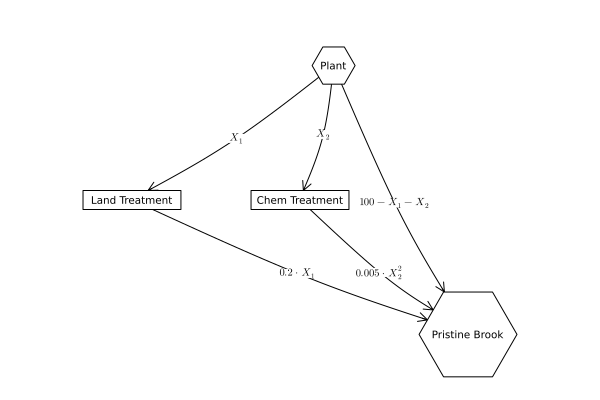

In [14]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1,3) => L"X_2", (1, 4) => L"100 - X_1 - X_2",(2, 4) => L"0.2 \cdot X_1",(3, 4) => L"0.005 \cdot X_2^2")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

##### 2.1

Volume discharged $= X_{tot} = 100 \frac{m^3}{day}$ \
Discharge Concentration $= C = 1 \frac{kg}{m^3}$ 

#### Land Treatment:

Cost: $S_1 = \frac{X_1}{20} \frac{dollars}{day}$ \
YUK Discharged: $W_1 = 0.2 \cdot X_1 \cdot C \frac{kg}{day}$

Discharge calculates mass of YUK that is not treated by soil, i.e. the amount of YUK in kg/day that discharges into the brook from the land treatment.

#### Chemical Treatment:

Efficiency: $e = 1 - 0.005 \cdot X_2$ \
Cost: $S_2 = 1.50 \cdot X_2 \frac{dollars}{day}$ \
YUK Discharged: $W_2 = (1 - e) \cdot X_2 \cdot C = (0.005 \cdot (X_2)^2) \cdot C \frac{kg}{day}$

Discharge calculates the mass of YUK not treated by chemical treatment, i.e. the amount of YUK in kg/day that discharges into the brook from the chemical treatment.

#### Direct Discharge

Cost: $S_3 = 0 \frac{dollars}{day}$ \
YUK Discharged: $W_3 = (X_{tot} - X_1 - X_2) \cdot C \frac{kg}{day}$

Discharge calculates the mass of YUK that gets discharged directly into the stream from the plant, in kg/day.

#### Ultimate Values

Cost: $S_{tot} = S_1 + S_2 = \frac{X_1}{20} + 1.50 \cdot X_2 \frac{dollars}{day}$ \
YUK Discharged: $W_{tot} = W_1 + W_2 + W_3 = 0.2 \cdot X_1 \cdot C + 0.005(X_2)^2 \cdot C + (X_{tot} - X_1 - X_2) \cdot C$ \
$W_{tot} = (X_1 \cdot (0.2 - 1) - X_2 + 0.005 \cdot (X_2)^2 + X_{tot}) \cdot C = (-0.8 \cdot X_1 - X_2 + 0.005 \cdot (X_2)^2 + X_{tot}) \cdot C \frac{kg}{day}$

$W_{tot}$ is the total mass of YUK in kg/day that gets discharged directly or indirectly to the brook. Its calculated by summing all three pathways, the direct discharge, the discharge post-land treatment, and the discharge post-chemical treatment.

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [9]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [10]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


In [59]:
function discharge(x, y, v=100, c=1)
    #x = x1, wastewater sent to land treatment, m3/d
    #y = x2, wastewater sentt to chemical treatment, m3/d
    #v = Wtot, amount of wastewater produced, m3/d
    #c = YUK concentration, m3/d
    cost = x^2/20 + 1.5*y
    waste = (v - 0.8*x - y + 0.005*y^2)*c
    return (cost, waste)
end

discharge (generic function with 3 methods)

Discharge function implements mathematical model from Problem 2.1, calculating the cost and amount of YUK discharged to brook.

In [60]:
@show discharge(60, 40)

discharge(60, 40) = (240.0, 20.0)


(240.0, 20.0)

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

In [110]:
vals = rand(Dirichlet(3,1), 1000)*100 #values for X1, X2, V - X1 - X2

x1_vals = vals[1,:]
x2_vals = vals[2,:]
x3_vals = vals[3,:]

results = discharge.(x1_vals, x2_vals);

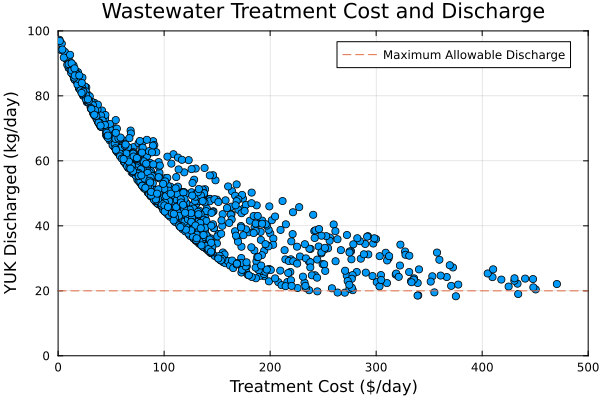

In [126]:
plot(results, seriestype=:scatter, label=:none, frame =:box)
title!("Wastewater Treatment Cost and Discharge")
xlabel!("Treatment Cost (\$/day)")
ylabel!("YUK Discharged (kg/day)")
xlims!(0, 500)
ylims!(0, 100)
hline!([20], linestyle=:dash, label="Maximum Allowable Discharge")

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.